# What are we binary classifying?

We are converting 10 digit classes into 2 classes.

**In today’s example:**

* Positive class (label = 1):  digits {0,1,2,3,4}
* Negative class (label = 0): digits {5,6,7,8,9}

**So the model learns:** Is this image from group A (0–4) or group B (5–9)?

This mimics medical tasks like:

* Cancerous (1) vs Normal (0)
* Disease present (1) vs absent (0)


In [ ]:
# --- Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Dataset, Subset, and datasets — What do they mean?
**torch.utils.data.Dataset**
* A blueprint/interface for any dataset. A dataset object must implement:

* __len__(self) → number of items
* __getitem__(self, idx) → return one item (usually (image, label))

**torch.utils.data.Subset**

A wrapper that takes:

an existing dataset, and
a list of indices, and exposes only those indices.
Use case: make a smaller dataset or create train/val splits without copying data.

**torchvision.datasets (imported as datasets)**

This is a collection of ready-made datasets, e.g.:

* datasets.MNIST
* datasets.CIFAR10
* datasets.ImageFolder

So:

* Dataset = generic interface you implement
* Subset = slice of an existing dataset
* datasets = prebuilt dataset classes from torchvision

In [ ]:
# --- Binary MNIST wrapper ---
class BinaryMNIST(Dataset):   # Defining a custom dataset that follows the Dataset interface
    """
    Maps MNIST digits to a binary label.
    Positive class (label=1): digits in pos_digits
    Negative class (label=0): digits not in pos_digits
    """
    def __init__(self, mnist_dataset, pos_digits=set([0,1,2,3,4])):
        self.ds = mnist_dataset  #stores MNIST dataset inside your wrapper
        self.pos_digits = pos_digits #defines which original digits become label 1, everything else becomes label 0


    def __len__(self):    # Your binary dataset has the same number of samples as the MNIST dataset.
        return len(self.ds)

    def __getitem__(self, idx):   # Get one sample from MNIST: x = image tensor, y = original digit (0–9)
        x, y = self.ds[idx]
        y_bin = 1.0 if int(y) in self.pos_digits else 0.0  #Convert digit → binary label: if digit ∈ {0..4} → 1.0, else → 0.0
        return x, torch.tensor(y_bin, dtype=torch.float32) #Return (image, binary_label) Why float32? Because BCEWithLogitsLoss expects float targets (not integer class indices).



In [ ]:
# --- Data ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_base = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_base  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_ds = BinaryMNIST(train_base, pos_digits=set([0,1,2,3,4])) #train_ds = binary version of training dataset
test_ds  = BinaryMNIST(test_base,  pos_digits=set([0,1,2,3,4])) #TEST_ds = binary version of testing dataset

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]


# What is pin_memory=True?
**When you train on GPU, your batch must move from CPU RAM → GPU VRAM.**

* pin_memory=True tells DataLoader to allocate batches in page-locked (pinned) memory, which makes CPU→GPU transfer faster.

**Rules of thumb:**

* If using CUDA: pin_memory=True is usually good.
* If using CPU only: it doesn’t help much.
It’s a performance optimization, not required for correctness.



In [ ]:
# --- Model: small CNN outputting 1 logit ---
class SmallBinaryCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), # (1 means 1 channel as mnist is a grayscale dataset , 32 kernels , 3*3 kernel size)
            nn.ReLU(),
            nn.MaxPool2d(2), # (kernel size = 2*2 , stride by default = 2)

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # 1 logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)     # (N,1)
        return x.squeeze(1)        # (N,)

model = SmallBinaryCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

sum(p.numel() for p in model.parameters())

420481

In [ ]:
# --- Train / Eval helpers ---
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval()
    all_probs = []
    all_targets = []

    for x, y in tqdm(loader, desc="eval", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)

    preds = (probs >= threshold).astype(np.int32)
    cm = confusion_matrix(targets.astype(np.int32), preds)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-12)   # recall for positive
    specificity = tn / (tn + fp + 1e-12)
    auc = roc_auc_score(targets, probs)

    return {
        "cm": cm,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "auc": auc,
        "probs": probs,
        "targets": targets
    }

In [ ]:
# --- Run training ---
epochs = 3
for epoch in range(1, epochs+1):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, test_loader)

    print(f"Epoch {epoch}/{epochs} | Train loss: {train_loss:.4f} | AUC: {metrics['auc']:.4f} "
          f"| Sens: {metrics['sensitivity']:.4f} | Spec: {metrics['specificity']:.4f}")
    print("Confusion matrix:\n", metrics["cm"])

Epoch 1/3 | Train loss: 0.0926 | AUC: 0.9988 | Sens: 0.9901 | Spec: 0.9805
Confusion matrix:
 [[4766   95]
 [  51 5088]]


Epoch 2/3 | Train loss: 0.0344 | AUC: 0.9995 | Sens: 0.9946 | Spec: 0.9827
Confusion matrix:
 [[4777   84]
 [  28 5111]]


Epoch 3/3 | Train loss: 0.0272 | AUC: 0.9997 | Sens: 0.9916 | Spec: 0.9903
Confusion matrix:
 [[4814   47]
 [  43 5096]]


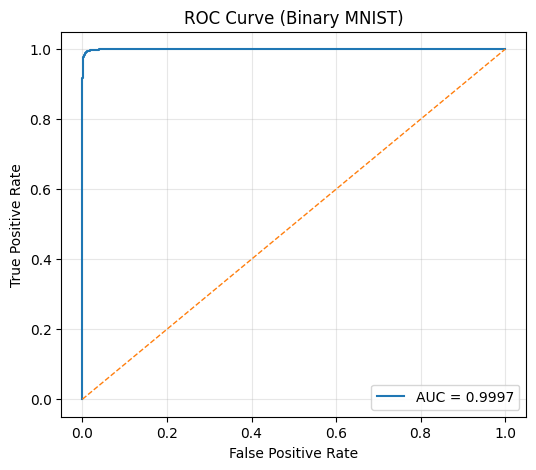

In [ ]:
# --- Plot ROC curve ---
metrics = evaluate(model, test_loader)
fpr, tpr, _ = roc_curve(metrics["targets"], metrics["probs"])

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {metrics['auc']:.4f}")
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary MNIST)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()